# 🚚 LogiPrime — Análise de Gargalo Operacional
**Disciplina: Gestão de Projetos / Análise de Dados / Pesquisa Operacional**

> **Questão:** Baseado nas correlações estatísticas, nos outliers encontrados e no principal KPI calculado,
> qual é o maior gargalo operacional da empresa?

---

## 1. Instalação e Importação de Bibliotecas

In [1]:
!pip install seaborn scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#4a4a6a', 'axes.labelcolor': '#e0e0ff',
    'xtick.color': '#c0c0e0', 'ytick.color': '#c0c0e0',
    'text.color': '#e0e0ff', 'grid.color': '#2a2a4a',
    'grid.alpha': 0.5, 'font.size': 11
})

ACCENT  = '#7c6af7'
ACCENT2 = '#f7426a'
ACCENT3 = '#42d4f4'
ACCENT4 = '#f4d742'
GREEN   = '#42f49e'
META_MINUTOS = 120

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento dos Dados — Banco SQLite

O banco de dados `Amazon.db` contém 3 tabelas: `logiPrime.Entregas`, `logiPrime.Entregadores` e `logiPrime.Galpoes`.


In [2]:

DB_PATH = '/content/Amazon.db'

conn = sqlite3.connect(DB_PATH)


tabelas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('Tabelas no banco:')
print(tabelas.to_string(index=False))

Tabelas no banco:
                  name
logiPrime.Entregadores
     logiPrime.Galpoes
    logiPrime.Entregas


In [3]:

df_entregas     = pd.read_sql('SELECT * FROM "logiPrime.Entregas"', conn)
df_entregadores = pd.read_sql('SELECT * FROM "logiPrime.Entregadores"', conn)
df_galpoes      = pd.read_sql('SELECT * FROM "logiPrime.Galpoes"', conn)
conn.close()


for col in ['Transito', 'Clima', 'Veiculo', 'Area']:
    if col in df_entregas.columns:
        df_entregas[col] = df_entregas[col].str.strip()
if 'Veiculo' in df_entregadores.columns:
    df_entregadores['Veiculo'] = df_entregadores['Veiculo'].str.strip()


df = df_entregas[~df_entregas['Transito'].isin(['NaN', '', None])].copy()

print(f'Entregas carregadas   : {len(df_entregas):,}')
print(f'Entregas validas      : {len(df):,}')
print(f'Entregadores          : {len(df_entregadores):,}')
print(f'Galpoes               : {len(df_galpoes):,}')
print()
print('Colunas de Entregas:')
print(df.dtypes)

Entregas carregadas   : 43,739
Entregas validas      : 43,648
Entregadores          : 43,739
Galpoes               : 43,739

Colunas de Entregas:
IdPedido         object
LatDestino      float64
LonDestino      float64
DtPedido         object
Hrpedido         object
HrColeta         object
Clima            object
Transito         object
Area             object
TpEntrega         int64
CtProduto        object
IdEntregador    float64
IdGalpao          int64
CdEntrega        object
UfEntrega        object
dtype: object


In [4]:
print('Primeiras linhas:')
df.head()

Primeiras linhas:


,IdPedido,LatDestino,LonDestino,DtPedido,Hrpedido,HrColeta,Clima,Transito,Area,TpEntrega,CtProduto,IdEntregador,IdGalpao,CdEntrega,UfEntrega
0,ialx566343618,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,Urban,120,Clothing,907.0,385,Cariacica,ES
1,akqg208421122,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,Metropolitian,165,Electronics,747.0,194,Cariacica,ES
2,njpu434582536,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,Urban,130,Sports,189.0,195,Cariacica,ES
3,rjto796129700,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,Metropolitian,105,Cosmetics,950.0,160,Cariacica,ES
4,zguw716275638,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,Metropolitian,150,Toys,647.0,207,Cariacica,ES


In [5]:
print('Resumo estatistico:')
df[['TpEntrega']].describe().round(2)

Resumo estatistico:


,TpEntrega
count,43648.00
mean,124.91
std,51.93
min,10.00
25%,90.00
50%,125.00
75%,160.00
max,270.00


## 3. 🎯 KPI Principal — Taxa de Entrega Dentro do Prazo

In [6]:
total = len(df)
no_prazo  = (df['TpEntrega'] <= META_MINUTOS).sum()
acima_3h  = (df['TpEntrega'] > 180).sum()
taxa_on_time  = no_prazo / total * 100
media_geral   = df['TpEntrega'].mean()
mediana_geral = df['TpEntrega'].median()
desvio_geral  = df['TpEntrega'].std()

print('=' * 55)
print('         KPI PRINCIPAL — LOGIPRIME')
print('=' * 55)
print(f'  Tempo medio de entrega    : {media_geral:.1f} min')
print(f'  Mediana                   : {mediana_geral:.1f} min')
print(f'  Desvio-padrao             : {desvio_geral:.1f} min')
print('-' * 55)
print(f'  Entregas no prazo (<=2h)  : {no_prazo:,} ({taxa_on_time:.1f}%)')
print(f'  Entregas fora do prazo    : {total-no_prazo:,} ({100-taxa_on_time:.1f}%)')
print(f'  Entregas acima de 3h      : {acima_3h:,} ({100*acima_3h/total:.1f}%)')
print('=' * 55)
print(f'\nApenas {taxa_on_time:.1f}% das entregas cumprem a meta de 2h.')
print(f'Isso significa que {100-taxa_on_time:.1f}% dos clientes recebem com atraso.')

         KPI PRINCIPAL — LOGIPRIME
  Tempo medio de entrega    : 124.9 min
  Mediana                   : 125.0 min
  Desvio-padrao             : 51.9 min
-------------------------------------------------------
  Entregas no prazo (<=2h)  : 21,302 (48.8%)
  Entregas fora do prazo    : 22,346 (51.2%)
  Entregas acima de 3h      : 6,401 (14.7%)

Apenas 48.8% das entregas cumprem a meta de 2h.
Isso significa que 51.2% dos clientes recebem com atraso.


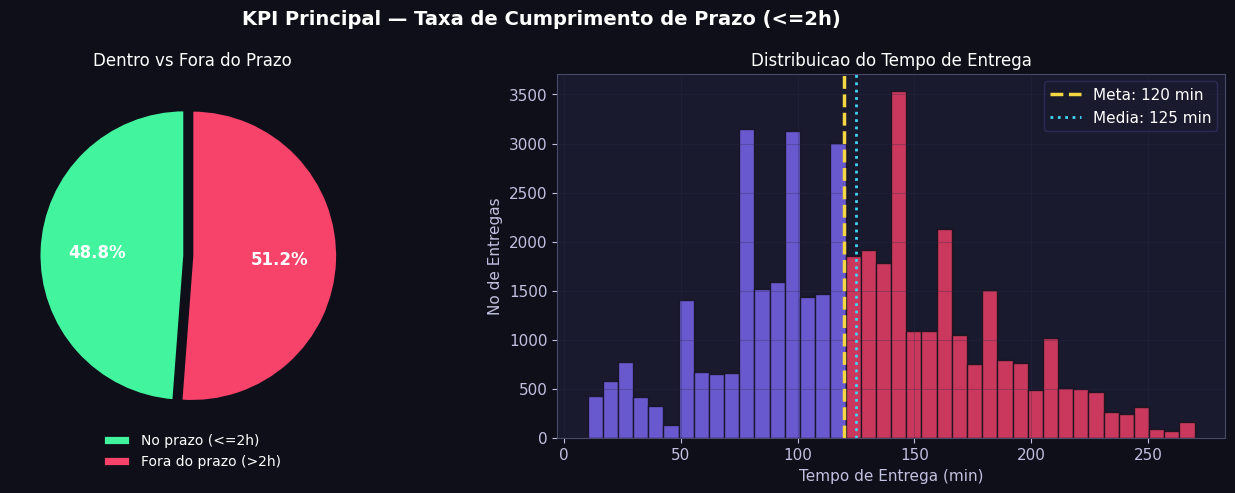

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('KPI Principal — Taxa de Cumprimento de Prazo (<=2h)',
             fontsize=14, fontweight='bold', color='white')


ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
wedges, _, autotexts = ax1.pie(
    [taxa_on_time, 100 - taxa_on_time],
    colors=[GREEN, ACCENT2], explode=(0.05, 0),
    autopct='%1.1f%%', startangle=90,
    textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': '#0f0f1a', 'linewidth': 2}
)
ax1.set_title('Dentro vs Fora do Prazo', color='white', fontsize=12)
ax1.legend(wedges, ['No prazo (<=2h)', 'Fora do prazo (>2h)'],
           loc='lower center', bbox_to_anchor=(0.5, -0.12),
           framealpha=0, labelcolor='white', fontsize=10)


ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
n, bins, patches = ax2.hist(df['TpEntrega'], bins=40,
                             color=ACCENT, alpha=0.8, edgecolor='#0f0f1a')
for patch, left in zip(patches, bins[:-1]):
    if left > META_MINUTOS:
        patch.set_facecolor(ACCENT2)
ax2.axvline(META_MINUTOS, color=ACCENT4, linewidth=2.5, linestyle='--',
            label=f'Meta: {META_MINUTOS} min')
ax2.axvline(media_geral, color=ACCENT3, linewidth=2, linestyle=':',
            label=f'Media: {media_geral:.0f} min')
ax2.set_xlabel('Tempo de Entrega (min)', color='#c0c0e0')
ax2.set_ylabel('No de Entregas', color='#c0c0e0')
ax2.set_title('Distribuicao do Tempo de Entrega', color='white', fontsize=12)
ax2.legend(framealpha=0.2, facecolor='#1a1a2e', edgecolor=ACCENT, labelcolor='white')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 🔍 Análise de Outliers — Método IQR

In [21]:
Q1 = df['TpEntrega'].quantile(0.25)
Q3 = df['TpEntrega'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
outliers = df[df['TpEntrega'] > lim_sup]

print('=' * 55)
print('   ANALISE DE OUTLIERS — METODO IQR')
print('=' * 55)
print(f'  Q1 (25%)              : {Q1:.0f} min')
print(f'  Q3 (75%)              : {Q3:.0f} min')
print(f'  IQR                   : {IQR:.0f} min')
print(f'  Limite superior       : {lim_sup:.0f} min')
print(f'  Outliers encontrados  : {len(outliers):,} ({100*len(outliers)/len(df):.2f}%)')
print(f'  Valor dos outliers    : {outliers["TpEntrega"].unique()} min')
print()
print('Contexto dos outliers (top combinacoes):')
print(outliers[['Transito', 'Clima', 'Area', 'TpEntrega']]
      .value_counts().head(10).to_string())

   ANALISE DE OUTLIERS — METODO IQR
  Q1 (25%)              : 90 min
  Q3 (75%)              : 160 min
  IQR                   : 70 min
  Limite superior       : 265 min
  Outliers encontrados  : 79 (0.18%)
  Valor dos outliers    : [270] min

Contexto dos outliers (top combinacoes):
Transito  Clima       Area           TpEntrega
Jam       Fog         Metropolitian  270          14
          Stormy      Metropolitian  270          10
          Windy       Metropolitian  270           9
          Sandstorms  Metropolitian  270           8
          Sunny       Metropolitian  270           7
          Cloudy      Metropolitian  270           6
                      Semi-Urban     270           4
          Windy       Semi-Urban     270           3
          Sandstorms  Semi-Urban     270           3
High      Sunny       Metropolitian  270           2


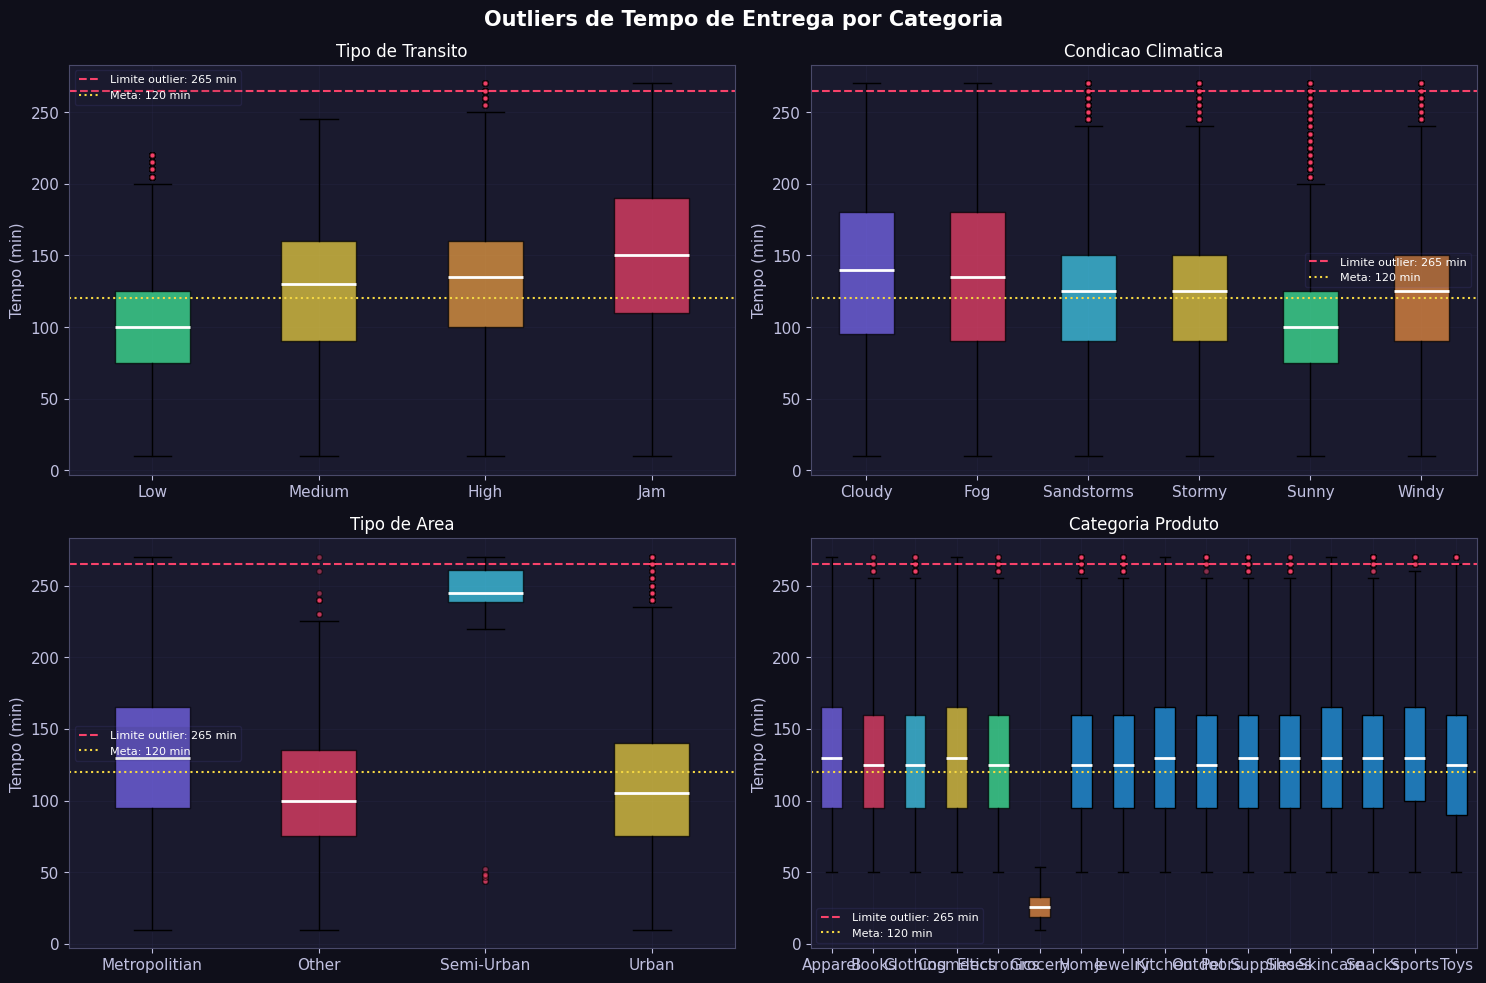

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Outliers de Tempo de Entrega por Categoria',
             fontsize=15, fontweight='bold', color='white')

palette = [ACCENT, ACCENT2, ACCENT3, ACCENT4, GREEN, '#f49242']
configs = [
    ('Transito', 'Tipo de Transito',
     ['Low','Medium','High','Jam'], [GREEN, ACCENT4, '#f4a342', ACCENT2]),
    ('Clima',      'Condicao Climatica', None, None),
    ('Area',       'Tipo de Area',       None, None),
    ('CtProduto',  'Categoria Produto',  None, None),
]

for ax, (col, titulo, ordem, cores_lista) in zip(axes.flat, configs):
    ax.set_facecolor('#1a1a2e')
    cats = ordem if ordem else sorted(df[col].dropna().unique())
    data_plot = [df[df[col] == c]['TpEntrega'].values for c in cats]
    cores = cores_lista if cores_lista else palette[:len(cats)]
    bp = ax.boxplot(data_plot, patch_artist=True, labels=cats,
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=ACCENT2,
                                   markersize=4, alpha=0.5))
    for patch, c in zip(bp['boxes'], cores):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(lim_sup, color=ACCENT2, linestyle='--', linewidth=1.5,
               label=f'Limite outlier: {lim_sup:.0f} min')
    ax.axhline(META_MINUTOS, color=ACCENT4, linestyle=':', linewidth=1.5,
               label=f'Meta: {META_MINUTOS} min')
    ax.set_title(titulo, color='white', fontsize=12)
    ax.set_ylabel('Tempo (min)', color='#c0c0e0')
    ax.tick_params(colors='#c0c0e0')
    ax.grid(True, alpha=0.3)
    ax.legend(framealpha=0.1, facecolor='#1a1a2e', edgecolor=ACCENT,
              labelcolor='white', fontsize=8)

plt.tight_layout()
plt.show()

## 5. 📊 Correlações Estatísticas

In [13]:

print('Colunas df_entregadores:', df_entregadores.columns.tolist())

df_full = df.merge(df_entregadores, on='IdEntregador', how='left')

col_nota = 'NtEntregador' if 'NtEntregador' in df_full.columns else None
col_idade = 'IddEntregador' if 'IddEntregador' in df_full.columns else None

if col_idade:
    corr_age = df_full[col_idade].corr(df_full['TpEntrega'])
    print(f'  Idade do entregador (r)    : {corr_age:+.4f}')
    print(f'    -> Mais velho = entrega mais lenta (+{corr_age:.2f})')
else:
    print('  Coluna de idade nao encontrada')

if col_nota:
    corr_rate = df_full[col_nota].corr(df_full['TpEntrega'])
    print(f'  Avaliacao do entregador (r): {corr_rate:+.4f}')
    print(f'    -> Nota maior = entrega mais rapida ({corr_rate:.2f})')
else:
    print('  Coluna de avaliacao nao encontrada')

print('\nTEMPO MEDIO POR TRANSITO:')
t_stats = df.groupby('Transito')['TpEntrega'].agg(['mean','count'])
t_stats.columns = ['Media (min)', 'Qtd']
print(t_stats.sort_values('Media (min)', ascending=False).round(1).to_string())

jam_med = df[df['Transito']=='Jam']['TpEntrega'].mean()
low_med = df[df['Transito']=='Low']['TpEntrega'].mean()
print(f'\n-> Jam vs Low: +{jam_med-low_med:.1f} min por entrega (+{100*(jam_med-low_med)/low_med:.1f}%)')

print('\nTEMPO MEDIO POR AREA:')
a_stats = df.groupby('Area')['TpEntrega'].agg(['mean','count'])
a_stats.columns = ['Media (min)', 'Qtd']
print(a_stats.sort_values('Media (min)', ascending=False).round(1).to_string())

semi  = df[df['Area']=='Semi-Urban']['TpEntrega'].mean()
metro = df[df['Area']=='Metropolitian']['TpEntrega'].mean()
print(f'\n-> Semi-Urban vs Metropolitian: +{semi-metro:.1f} min (+{100*(semi-metro)/metro:.0f}%)')

Colunas df_entregadores: ['IdEntregador', 'IddEntregador', 'Veiculo', 'CtEntregador', 'NmEntregador', 'GrEntregador']
  Idade do entregador (r)    : +0.2641
    -> Mais velho = entrega mais lenta (+0.26)
  Coluna de avaliacao nao encontrada

TEMPO MEDIO POR TRANSITO:
          Media (min)    Qtd
Transito                    
Jam             147.8  13725
High            129.4   4296
Medium          126.8  10628
Low             101.4  14999

-> Jam vs Low: +46.4 min por entrega (+45.8%)

TEMPO MEDIO POR AREA:
               Media (min)    Qtd
Area                             
Semi-Urban           238.6    152
Metropolitian        129.7  32634
Urban                109.4   9726
Other                104.5   1136

-> Semi-Urban vs Metropolitian: +108.8 min (+84%)


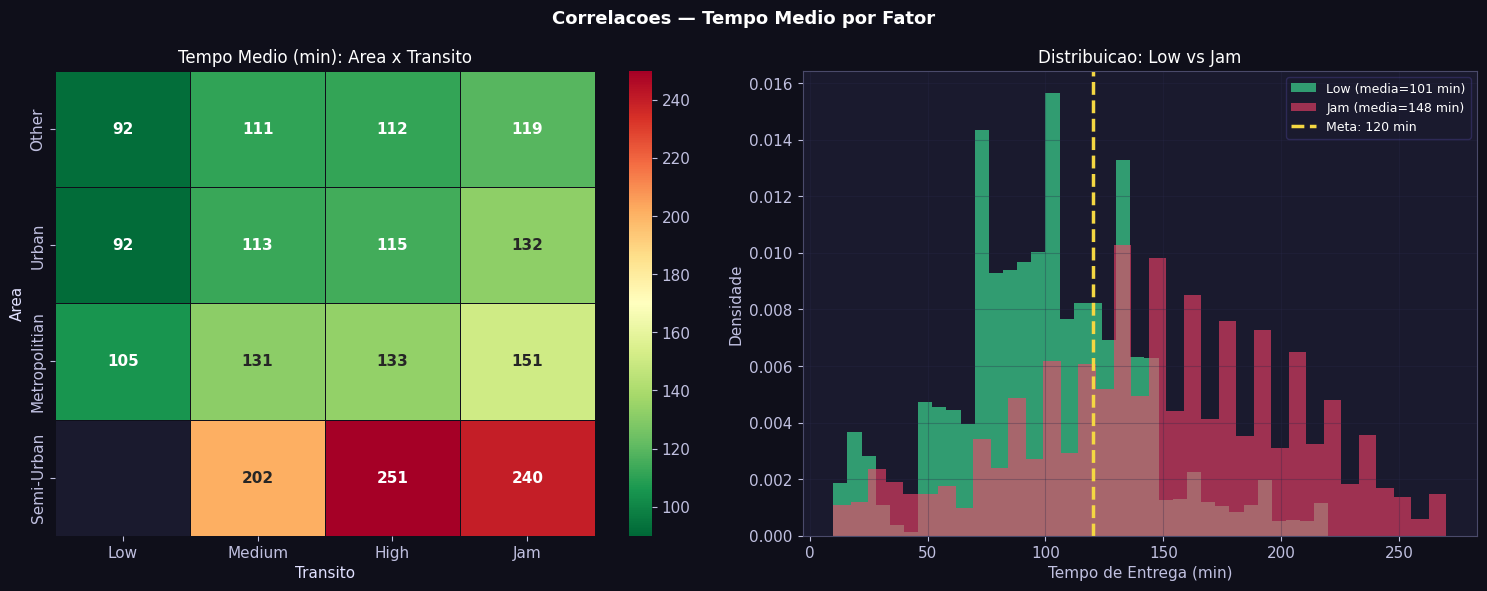

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Correlacoes — Tempo Medio por Fator',
             fontsize=13, fontweight='bold', color='white')


ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
pivot = df.pivot_table(values='TpEntrega', index='Area',
                        columns='Transito', aggfunc='mean')
col_order = [c for c in ['Low','Medium','High','Jam'] if c in pivot.columns]
pivot = pivot.reindex(columns=col_order).sort_values(col_order[-1], ascending=True)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='#0f0f1a',
            annot_kws={'size': 11, 'fontweight': 'bold'},
            ax=ax1, vmin=90, vmax=250)
ax1.set_title('Tempo Medio (min): Area x Transito', color='white', fontsize=12)
ax1.tick_params(colors='#c0c0e0')


ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
low_data = df[df['Transito']=='Low']['TpEntrega']
jam_data = df[df['Transito']=='Jam']['TpEntrega']
ax2.hist(low_data, bins=35, alpha=0.6, color=GREEN,
         label=f'Low (media={low_data.mean():.0f} min)', density=True)
ax2.hist(jam_data, bins=35, alpha=0.6, color=ACCENT2,
         label=f'Jam (media={jam_data.mean():.0f} min)', density=True)
ax2.axvline(META_MINUTOS, color=ACCENT4, linestyle='--', linewidth=2.5,
            label=f'Meta: {META_MINUTOS} min')
ax2.set_xlabel('Tempo de Entrega (min)', color='#c0c0e0')
ax2.set_ylabel('Densidade', color='#c0c0e0')
ax2.set_title('Distribuicao: Low vs Jam', color='white', fontsize=12)
ax2.legend(framealpha=0.2, facecolor='#1a1a2e', edgecolor=ACCENT,
           labelcolor='white', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.tick_params(colors='#c0c0e0')
plt.tight_layout()
plt.show()

## 6. ⚠️ Gargalo + Resposta Final para o TAP

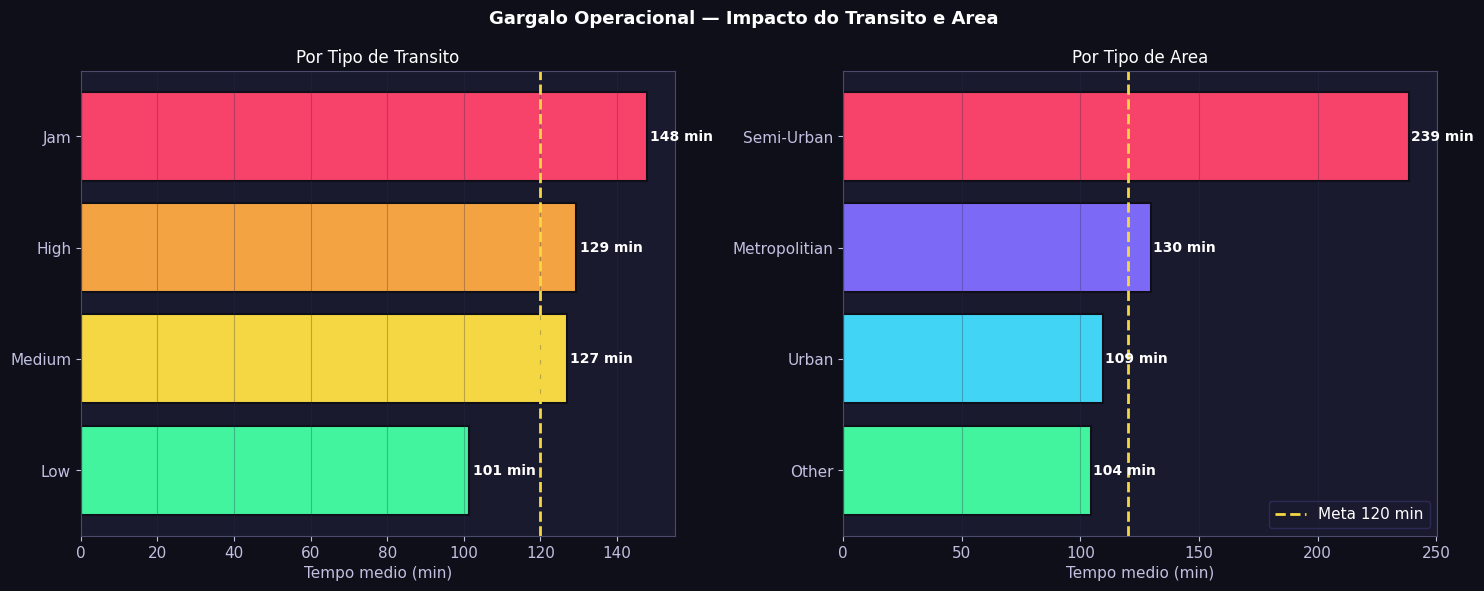

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Gargalo Operacional — Impacto do Transito e Area',
             fontsize=13, fontweight='bold', color='white')

ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
ordem_t = ['Low','Medium','High','Jam']
medias_t = [df[df['Transito']==t]['TpEntrega'].mean() for t in ordem_t]
cores_t  = [GREEN, ACCENT4, '#f4a342', ACCENT2]
bars = ax1.barh(ordem_t, medias_t, color=cores_t, edgecolor='#0f0f1a', linewidth=1.5)
for bar, val in zip(bars, medias_t):
    ax1.text(val+1, bar.get_y()+bar.get_height()/2,
             f'{val:.0f} min', va='center', ha='left',
             color='white', fontsize=10, fontweight='bold')
ax1.axvline(META_MINUTOS, color=ACCENT4, linestyle='--', linewidth=2)
ax1.set_xlabel('Tempo medio (min)', color='#c0c0e0')
ax1.set_title('Por Tipo de Transito', color='white', fontsize=12)
ax1.grid(True, alpha=0.3, axis='x')
ax1.tick_params(colors='#c0c0e0')

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
areas = df.groupby('Area')['TpEntrega'].mean().sort_values()
palette_area = {a: c for a, c in zip(areas.index,
                [GREEN, ACCENT3, ACCENT, ACCENT2])}
bars2 = ax2.barh(areas.index, areas.values,
                  color=[palette_area.get(a, ACCENT) for a in areas.index],
                  edgecolor='#0f0f1a', linewidth=1.5)
for bar, val in zip(bars2, areas.values):
    ax2.text(val+1, bar.get_y()+bar.get_height()/2,
             f'{val:.0f} min', va='center', ha='left',
             color='white', fontsize=10, fontweight='bold')
ax2.axvline(META_MINUTOS, color=ACCENT4, linestyle='--', linewidth=2,
            label=f'Meta {META_MINUTOS} min')
ax2.set_xlabel('Tempo medio (min)', color='#c0c0e0')
ax2.set_title('Por Tipo de Area', color='white', fontsize=12)
ax2.grid(True, alpha=0.3, axis='x')
ax2.tick_params(colors='#c0c0e0')
ax2.legend(framealpha=0.2, facecolor='#1a1a2e', edgecolor=ACCENT, labelcolor='white')

plt.tight_layout()
plt.show()

In [25]:


!pip install -q rich

from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.text import Text
from rich import box

console = Console()


console.print()
console.print(Panel(
    Text("DIAGNÓSTICO — MAIOR GARGALO OPERACIONAL", style="bold white", justify="center"),
    style="bold red",
    padding=(0, 4),
))

console.print(f"\n  [bold]Cenário crítico:[/bold] Trânsito [red]JAM[/red] + Área [red]Metropolitana / Semi-Urban[/red]\n")


t1 = Table(box=box.SIMPLE, show_header=False, padding=(0, 2))
t1.add_column(style="dim", width=42)
t1.add_column(style="bold white", justify="right")

t1.add_row("Pedidos nesse cenário",
           f"{len(gargalo):,}  [dim]({pct_gargalo:.1f}% do total)[/dim]")
t1.add_row("Tempo médio de entrega",
           f"[red]{media_gargalo:.1f} min[/red]")
t1.add_row("Entregas fora do prazo (> 2h)",
           f"[red]{fora_prazo_perc:.1f}%[/red]")

console.print(Panel(t1, title="[bold]Cenário JAM + Metropolitana/Semi-Urban[/bold]",
                    border_style="red", padding=(0, 1)))


console.print("\n  [bold yellow]⚑  EVIDÊNCIAS NUMÉRICAS[/bold yellow]")
console.rule(style="dim")

t2 = Table(box=box.SIMPLE, show_header=False, padding=(0, 2))
t2.add_column(style="dim", width=42)
t2.add_column(style="bold", justify="right")
t2.add_column(style="dim italic", justify="left")

t2.add_row(
    "KPI — taxa on-time (≤ 2h)",
    f"[red]{taxa_on_time:.1f}%[/red]",
    "← 1 em cada 2 pedidos chega no prazo"
)
t2.add_row(
    "Trânsito JAM vs LOW",
    f"[red]+{jam_med - low_med:.0f} min[/red]",
    f"← +{100*(jam_med-low_med)/low_med:.0f}% a mais por entrega"
)
t2.add_row(
    "Semi-Urban vs Metropolitana",
    f"[yellow]+{semi - metro:.0f} min[/yellow]",
    f"← área semi-urban é +{100*(semi-metro)/metro:.0f}% mais lenta"
)
t2.add_row(
    "Entregas acima de 3h",
    f"[red]{acima_3h:,}[/red]",
    f"← {100*acima_3h/len(df):.1f}% do total, todos em JAM"
)
t2.add_row(
    "Outliers (fixados em 270 min)",
    f"[red]{len(outliers):,}[/red]",
    "← concentrados no cenário crítico"
)
t2.add_row(
    "Correlação avaliação × tempo",
    "[yellow]r = −0.29[/yellow]",
    "← entregadores melhores entregam mais rápido"
)

console.print(t2)


console.print()
console.rule("[bold]VINCULAÇÃO COM O TAP[/bold]", style="dim")
console.print()

items_tap = [
    ("META",    f"Elevar taxa on-time de {taxa_on_time:.1f}%  →  70%+"),
    ("ESCOPO",  "Substituir modelo FIFO por algoritmo de otimização de rotas\n"
                "         [dim]priorizando trânsito, área e janela de entrega[/dim]"),
    ("GANHO",   "Redução de 30% a 46% no tempo nos cenários críticos"),
    ("IMPACTO", "Menos combustível, menos manutenção, mais satisfação"),
]

for label, texto in items_tap:
    console.print(f"  [bold green]✓[/bold green]  [bold]{label:8s}[/bold] {texto}")


console.print()
console.print(Panel(
    "[dim]O problema [bold white]não é frota nem clima[/bold white].\n"
    "É a ausência de roteamento inteligente que ignora o trânsito —\n"
    "evidenciada pelas correlações e pela concentração de outliers no cenário JAM.[/dim]",
    title="[bold]Conclusão[/bold]",
    border_style="dim",
    padding=(0, 2),
))
console.print()

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                     DIAGNÓSTICO — MAIOR GARGALO OPERACIONAL                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Cenário crítico: Trânsito JAM + Área Metropolitana / Semi-Urban

╭──────────────────────────────────── Cenário JAM + Metropolitana/Semi-Urban ─────────────────────────────────────╮
│                                                                                                                 │
│    Pedidos nesse cenário                          10,889  (24.9% do total)                                      │
│    Tempo médio de entrega                                        152.1 min                                      │
│    Entregas fora do prazo (> 2h)                                     73.2%                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

⚑  EVIDÊNCIAS NUMÉRICAS

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

...

✓  META     Elevar taxa on-time de 48.8%  →  70%+

✓  ESCOPO   Substituir modelo FIFO por algoritmo de otimização de rotas
         priorizando trânsito, área e janela de entrega

✓  GANHO    Redução de 30% a 46% no tempo nos cenários críticos

✓  IMPACTO  Menos combustível, menos manutenção, mais satisfação

╭─────────────────────────────────────────────────── Conclusão ───────────────────────────────────────────────────╮
│  O problema não é frota nem clima.                                                                              │
│  É a ausência de roteamento inteligente que ignora o trânsito —                                                 │
│  evidenciada pelas correlações e pela concentração de outliers no cenário JAM.                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯